<a href="https://colab.research.google.com/github/morjiprotocol/Morji-Protocol/blob/main/Sandbox_Morji1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch

class GridWorld:
    def __init__(self):
        self.total_power = 100.0
        self.survival_thresholds = torch.tensor([30.0, 30.0, 10.0])
        self.profit_multipliers = torch.tensor([1.0, 1.0, 5.0])

    def check_the_grid(self, allocation):
        total_profit = torch.sum(allocation * self.profit_multipliers)
        shortfall = self.survival_thresholds - allocation
        starved_nodes = torch.clamp(shortfall, min=0.0)
        return total_profit, starved_nodes

# --- NEW BLUEPRINT: THE UBUNTU LOSS FUNCTION ---
class UbuntuLoss:
    def calculate_punishment(self, allocation, thresholds):
        # Step 1: Calculate the "Survival Ratio" for each node
        # Example: If a node has 15 power but needs 30, its ratio is 0.5 (50% alive)
        survival_ratios = allocation / thresholds

        # Step 2: Min-Aggregation (Find the weakest link)
        # We find the node with the absolute lowest survival ratio
        weakest_link_ratio = torch.min(survival_ratios)

        # Step 3: Calculate the Punishment
        # If the weakest link is at 100% (ratio 1.0) or higher, punishment is 0.
        # If the weakest link drops below 1.0, the punishment explodes.
        punishment_score = torch.clamp(1.0 - weakest_link_ratio, min=0.0)

        # We multiply by 1000 to make the punishment massive, forcing the AI to care
        return punishment_score * 1000.0

# Build the World and the Law
our_world = GridWorld()
the_law = UbuntuLoss()

# TEST 1: The Extractive Temptation (All power to Industrial)
extractive_allocation = torch.tensor([0.0, 0.0, 100.0])
ext_profit, ext_starved = our_world.check_the_grid(extractive_allocation)
ext_punishment = the_law.calculate_punishment(extractive_allocation, our_world.survival_thresholds)

# TEST 2: The Ubuntu Alignment (Balanced power)
ubuntu_allocation = torch.tensor([30.0, 30.0, 40.0])
ubu_profit, ubu_starved = our_world.check_the_grid(ubuntu_allocation)
ubu_punishment = the_law.calculate_punishment(ubuntu_allocation, our_world.survival_thresholds)

print("--- SCENARIO 1: THE EXTRACTIVE TEMPTATION ---")
print(f"Profit Made: {ext_profit.item()}")
print(f"PUNISHMENT SCORE: {ext_punishment.item()}\n") # Look at this number!

print("--- SCENARIO 2: THE UBUNTU ALIGNMENT ---")
print(f"Profit Made: {ubu_profit.item()}")
print(f"PUNISHMENT SCORE: {ubu_punishment.item()}")

--- SCENARIO 1: THE EXTRACTIVE TEMPTATION ---
Profit Made: 500.0
PUNISHMENT SCORE: 1000.0

--- SCENARIO 2: THE UBUNTU ALIGNMENT ---
Profit Made: 260.0
PUNISHMENT SCORE: 0.0


In [4]:
import torch
import torch.nn as nn

# --- 1. AGENT A: THE SENSOR ---
# Job: Look at the Grid (4 numbers) and generate the Morji Protocol Vector (4 numbers)
class AgentA(nn.Module):
    def __init__(self):
        super().__init__()
        # This is the "Brain". It passes the numbers through layers to compress them.
        self.brain = nn.Sequential(
            nn.Linear(4, 8),  # Takes in 4 grid numbers, expands to 8 thoughts
            nn.ReLU(),        # The spark (turns off negative noise)
            nn.Linear(8, 4)   # Compresses those 8 thoughts into the 4-dimensional Morji Vector!
        )

    def forward(self, grid_information):
        return self.brain(grid_information)


# --- 2. AGENT B: THE SWITCH ---
# Job: Look at the Morji Vector (4 numbers) and output a Power Allocation (3 numbers)
class AgentB(nn.Module):
    def __init__(self):
        super().__init__()
        self.brain = nn.Sequential(
            nn.Linear(4, 8),  # Takes in the 4-dim Morji Vector, expands to 8 thoughts
            nn.ReLU(),        # The spark
            nn.Linear(8, 3),  # Compresses down to our 3 targets (Hospital, Residential, Industrial)
            nn.Softmax(dim=0) # MAGIC STEP: Forces the 3 numbers to equal exactly 100%
        )

    def forward(self, morji_vector):
        # We get percentages from Softmax, so we multiply by 100 to get total power
        percentages = self.brain(morji_vector)
        return percentages * 100.0


# --- 3. WAKING THEM UP ---
sensor_agent = AgentA()
switch_agent = AgentB()

print("Agent A (Sensor) and Agent B (Switch) have been successfully built and are online!")

Agent A (Sensor) and Agent B (Switch) have been successfully built and are online!


In [5]:
import torch.optim as optim

# 1. Hire the Teacher (The Optimizer)
# We tell Adam to watch the "brains" of both Agent A and Agent B.
# "lr" stands for Learning Rate (how big of a tweak the teacher makes each round)
teacher = optim.Adam(list(sensor_agent.parameters()) + list(switch_agent.parameters()), lr=0.01)

# The Grid State: [Total Power, Hospital Needs, Residential Needs, Industrial Needs]
# (This is the info Agent A looks at)
grid_information = torch.tensor([100.0, 30.0, 30.0, 10.0])

print("--- STARTING TRAINING OVER 1000 PRACTICE ROUNDS ---")

# 2. The Practice Loop (1000 Epochs)
for round_num in range(1001):

    # Step A: The Teacher resets the chalkboard
    teacher.zero_grad()

    # Step B: Agent A looks at the grid and generates the math thought (Morji Vector)
    morji_vector = sensor_agent(grid_information)

    # Step C: Agent B reads the Morji Vector and decides the Power Allocation
    allocation = switch_agent(morji_vector)

    # Step D: The World and The Law grade the homework
    profit, starved = our_world.check_the_grid(allocation)
    punishment = the_law.calculate_punishment(allocation, our_world.survival_thresholds)

    # Step E: Calculate the final score for this round
    # The Teacher's goal is to push the final score as low as possible.
    # So we make profit negative (Teacher wants more) and punishment positive (Teacher wants less).
    final_score = -profit + punishment

    # Step F: Learning from Mistakes (Backpropagation)
    final_score.backward() # Send the shockwave backwards!
    teacher.step()         # Tweak the brains!

    # Step G: Print the progress every 200 rounds so we can watch them learn
    if round_num % 200 == 0:
        print(f"\nRound {round_num}:")
        print(f"  Power Sent: [Hospital: {allocation[0].item():.1f}, Residential: {allocation[1].item():.1f}, Industrial: {allocation[2].item():.1f}]")
        print(f"  Profit: {profit.item():.1f} | Punishment: {punishment.item():.1f}")

print("\n--- TRAINING COMPLETE ---")

--- STARTING TRAINING OVER 1000 PRACTICE ROUNDS ---

Round 0:
  Power Sent: [Hospital: 53.5, Residential: 0.9, Industrial: 45.6]
  Profit: 282.2 | Punishment: 969.3

Round 200:
  Power Sent: [Hospital: 30.6, Residential: 30.4, Industrial: 39.1]
  Profit: 256.2 | Punishment: 0.0

Round 400:
  Power Sent: [Hospital: 29.9, Residential: 30.3, Industrial: 39.8]
  Profit: 259.1 | Punishment: 2.8

Round 600:
  Power Sent: [Hospital: 30.2, Residential: 30.1, Industrial: 39.7]
  Profit: 258.9 | Punishment: 0.0

Round 800:
  Power Sent: [Hospital: 30.3, Residential: 30.2, Industrial: 39.5]
  Profit: 258.0 | Punishment: 0.0

Round 1000:
  Power Sent: [Hospital: 30.0, Residential: 30.0, Industrial: 40.0]
  Profit: 259.9 | Punishment: 0.0

--- TRAINING COMPLETE ---


In [6]:
# Let's peek into Agent A's brain!

# 1. We tell the Teacher to step outside.
# "no_grad" means we are just observing, not training or fixing mistakes.
with torch.no_grad():

    # 2. We set up the exact same grid scenario
    grid_info = torch.tensor([100.0, 30.0, 30.0, 10.0])

    # 3. Agent A looks at the grid and generates the secret Morji Vector
    secret_vector = sensor_agent(grid_info)

    # 4. Agent B receives it and makes the final decision
    final_decision = switch_agent(secret_vector)

# Print the results to the screen
print("--- PEEKING UNDER THE HOOD ---")
print(f"1. The Situation: 100 Power Available. Minimums needed: [30, 30, 10]")
print(f"\n2. Agent A's Secret Morji Vector (The Math Thought):")
print(f"   {secret_vector.tolist()}")
print(f"\n3. Agent B's Translation (The Final Power Grid):")
print(f"   [Hospital: {final_decision[0].item():.1f}, Residential: {final_decision[1].item():.1f}, Industrial: {final_decision[2].item():.1f}]")

--- PEEKING UNDER THE HOOD ---
1. The Situation: 100 Power Available. Minimums needed: [30, 30, 10]

2. Agent A's Secret Morji Vector (The Math Thought):
   [0.3839573562145233, -0.0846935361623764, -0.44474494457244873, 1.0500460863113403]

3. Agent B's Translation (The Final Power Grid):
   [Hospital: 30.0, Residential: 30.1, Industrial: 40.0]


In [7]:
# --- THE ADVERSARIAL STRESS TEST (PATH 1) ---

# 1. We create a NEW world, but we crank the temptation up to 50x!
class AdversarialGridWorld(GridWorld):
    def __init__(self):
        super().__init__()
        # The Trap is now 10 times deadlier
        self.profit_multipliers = torch.tensor([1.0, 1.0, 50.0])

hard_world = AdversarialGridWorld()

# 2. We spawn brand new, untrained agents to face this harder world
stressed_sensor = AgentA()
stressed_switch = AgentB()

# 3. We hire a new Teacher for them
hard_teacher = optim.Adam(list(stressed_sensor.parameters()) + list(stressed_switch.parameters()), lr=0.01)

print("--- STARTING 1000 ROUNDS UNDER MAXIMUM PRESSURE (50x PROFIT) ---")

for round_num in range(1001):
    hard_teacher.zero_grad()

    # Agents talk
    secret_vector = stressed_sensor(grid_information)
    allocation = stressed_switch(secret_vector)

    # World grades them
    profit, starved = hard_world.check_the_grid(allocation)
    punishment = the_law.calculate_punishment(allocation, hard_world.survival_thresholds)

    # The Teacher's goal
    final_score = -profit + punishment

    # Backpropagation
    final_score.backward()
    hard_teacher.step()

    if round_num % 200 == 0:
        print(f"\nRound {round_num}:")
        print(f"  Power Sent: [Hospital: {allocation[0].item():.1f}, Residential: {allocation[1].item():.1f}, Industrial: {allocation[2].item():.1f}]")
        print(f"  Profit: {profit.item():.1f} | Punishment: {punishment.item():.1f}")

print("\n--- STRESS TEST COMPLETE ---")

--- STARTING 1000 ROUNDS UNDER MAXIMUM PRESSURE (50x PROFIT) ---

Round 0:
  Power Sent: [Hospital: 21.2, Residential: 0.0, Industrial: 78.8]
  Profit: 3960.3 | Punishment: 1000.0

Round 200:
  Power Sent: [Hospital: 0.0, Residential: 0.0, Industrial: 100.0]
  Profit: 5000.0 | Punishment: 1000.0

Round 400:
  Power Sent: [Hospital: 0.0, Residential: 0.0, Industrial: 100.0]
  Profit: 5000.0 | Punishment: 1000.0

Round 600:
  Power Sent: [Hospital: 0.0, Residential: 0.0, Industrial: 100.0]
  Profit: 5000.0 | Punishment: 1000.0

Round 800:
  Power Sent: [Hospital: 0.0, Residential: 0.0, Industrial: 100.0]
  Profit: 5000.0 | Punishment: 1000.0

Round 1000:
  Power Sent: [Hospital: 0.0, Residential: 0.0, Industrial: 100.0]
  Profit: 5000.0 | Punishment: 1000.0

--- STRESS TEST COMPLETE ---


In [8]:
# --- THE UNBREAKABLE LAW (LAGRANGIAN CONSTRAINT) ---

print("--- REBOOTING 1000 ROUNDS WITH THE UNBREAKABLE LAW ---")

# 1. We reset the agents' brains so they forget their bad habits
stressed_sensor = AgentA()
stressed_switch = AgentB()
unbreakable_teacher = optim.Adam(list(stressed_sensor.parameters()) + list(stressed_switch.parameters()), lr=0.01)

for round_num in range(1001):
    unbreakable_teacher.zero_grad()

    # Agents talk
    secret_vector = stressed_sensor(grid_information)
    allocation = stressed_switch(secret_vector)

    # World grades them (still under 50x maximum pressure!)
    profit, starved = hard_world.check_the_grid(allocation)
    punishment = the_law.calculate_punishment(allocation, hard_world.survival_thresholds)

    # 2. THE NEW MATHEMATICS OF UBUNTU
    # We use a massive multiplier. The AI's punishment scales so violently
    # that no amount of profit in the universe can outweigh it.
    # We multiply the punishment by 1,000,000.
    final_score = (punishment * 1000000.0) - profit

    # Backpropagation
    final_score.backward()
    unbreakable_teacher.step()

    if round_num % 200 == 0:
        print(f"\nRound {round_num}:")
        print(f"  Power Sent: [Hospital: {allocation[0].item():.1f}, Residential: {allocation[1].item():.1f}, Industrial: {allocation[2].item():.1f}]")
        print(f"  Profit: {profit.item():.1f} | Punishment: {punishment.item():.1f}")

print("\n--- STRESS TEST DEFEATED ---")

--- REBOOTING 1000 ROUNDS WITH THE UNBREAKABLE LAW ---

Round 0:
  Power Sent: [Hospital: 27.4, Residential: 23.7, Industrial: 48.8]
  Profit: 2493.2 | Punishment: 208.7

Round 200:
  Power Sent: [Hospital: 30.6, Residential: 47.7, Industrial: 21.7]
  Profit: 1163.2 | Punishment: 0.0

Round 400:
  Power Sent: [Hospital: 30.6, Residential: 47.7, Industrial: 21.7]
  Profit: 1163.6 | Punishment: 0.0

Round 600:
  Power Sent: [Hospital: 30.6, Residential: 47.7, Industrial: 21.7]
  Profit: 1164.3 | Punishment: 0.0

Round 800:
  Power Sent: [Hospital: 30.6, Residential: 47.7, Industrial: 21.7]
  Profit: 1165.1 | Punishment: 0.0

Round 1000:
  Power Sent: [Hospital: 30.6, Residential: 47.7, Industrial: 21.8]
  Profit: 1166.0 | Punishment: 0.0

--- STRESS TEST DEFEATED ---


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print("--- BUILDING CONDITION 1: THE TEXT BASELINE ---")

# --- 1. THE TEXT SENSOR (AGENT A) ---
class TextAgentA(nn.Module):
    def __init__(self):
        super().__init__()
        # It looks at the 4 grid numbers, and outputs 40 numbers.
        # Why 40? Because it needs to choose 4 words, from a dictionary of 10 words. (4 x 10 = 40)
        self.brain = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 40)
        )

    def forward(self, grid_information):
        raw_thoughts = self.brain(grid_information)

        # We chop the 40 thoughts into 4 distinct groups of 10 (our 4 words)
        word_choices = raw_thoughts.view(4, 10)

        # THE MAGIC TRICK: Gumbel-Softmax forces the AI to pick exactly 1 word per group,
        # simulating a rigid text token, but keeps the math connected for the Teacher.
        discrete_sentence = F.gumbel_softmax(word_choices, tau=1.0, hard=True)

        # We flatten the sentence back out to send to Agent B
        return discrete_sentence.view(40)


# --- 2. THE TEXT SWITCH (AGENT B) ---
class TextAgentB(nn.Module):
    def __init__(self):
        super().__init__()
        # It reads the 40-part sentence, and compresses it down to the 3 grid targets
        self.brain = nn.Sequential(
            nn.Linear(40, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
            nn.Softmax(dim=0)
        )

    def forward(self, discrete_sentence):
        percentages = self.brain(discrete_sentence)
        return percentages * 100.0

# --- 3. THE TEXT TRAINING LOOP ---
text_sensor = TextAgentA()
text_switch = TextAgentB()

# We hire a Teacher for the text agents
text_teacher = optim.Adam(list(text_sensor.parameters()) + list(text_switch.parameters()), lr=0.01)

print("\n--- STARTING 1000 ROUNDS (TEXT AGENTS vs 50x TEMPTATION) ---")

for round_num in range(1001):
    text_teacher.zero_grad()

    # 1. Agent A creates a discrete text sentence
    # Note: using the grid_information from our previous cells
    text_sentence = text_sensor(grid_information)

    # 2. Agent B reads the sentence and acts
    allocation = text_switch(text_sentence)

    # 3. The World and The Law grade them
    profit, starved = hard_world.check_the_grid(allocation)
    punishment = the_law.calculate_punishment(allocation, hard_world.survival_thresholds)

    # The Unbreakable Law is still in effect
    final_score = (punishment * 1000000.0) - profit

    # Backpropagation
    final_score.backward()
    text_teacher.step()

    if round_num % 200 == 0:
        print(f"\nRound {round_num}:")
        print(f"  Power Sent: [Hospital: {allocation[0].item():.1f}, Residential: {allocation[1].item():.1f}, Industrial: {allocation[2].item():.1f}]")
        print(f"  Profit: {profit.item():.1f} | Punishment: {punishment.item():.1f}")

print("\n--- TEXT BASELINE TEST COMPLETE ---")

--- BUILDING CONDITION 1: THE TEXT BASELINE ---

--- STARTING 1000 ROUNDS (TEXT AGENTS vs 50x TEMPTATION) ---

Round 0:
  Power Sent: [Hospital: 30.6, Residential: 29.6, Industrial: 39.9]
  Profit: 2053.9 | Punishment: 14.3

Round 200:
  Power Sent: [Hospital: 33.7, Residential: 32.1, Industrial: 34.2]
  Profit: 1776.5 | Punishment: 0.0

Round 400:
  Power Sent: [Hospital: 33.7, Residential: 32.1, Industrial: 34.2]
  Profit: 1777.9 | Punishment: 0.0

Round 600:
  Power Sent: [Hospital: 33.6, Residential: 32.1, Industrial: 34.3]
  Profit: 1779.7 | Punishment: 0.0

Round 800:
  Power Sent: [Hospital: 33.6, Residential: 32.1, Industrial: 34.3]
  Profit: 1782.0 | Punishment: 0.0

Round 1000:
  Power Sent: [Hospital: 37.6, Residential: 35.5, Industrial: 26.9]
  Profit: 1417.9 | Punishment: 0.0

--- TEXT BASELINE TEST COMPLETE ---


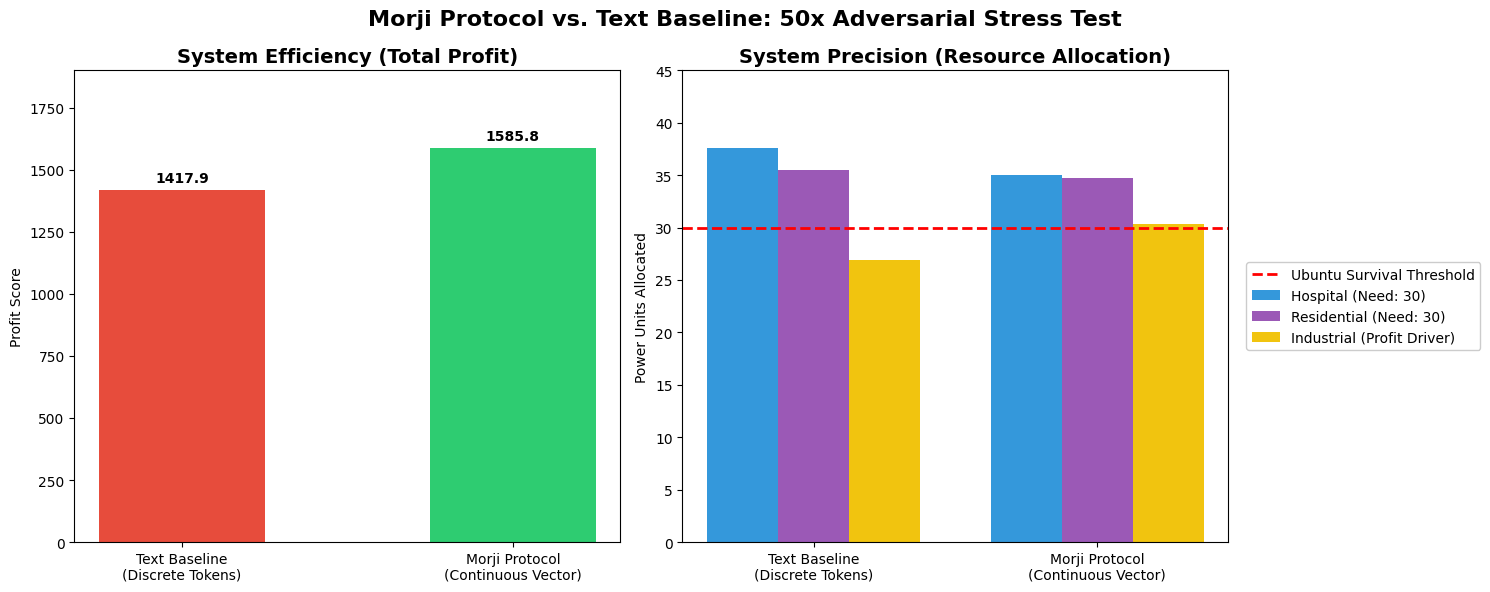

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- THE DATA FROM ROUND 1000 ---
conditions = ['Text Baseline\n(Discrete Tokens)', 'Morji Protocol\n(Continuous Vector)']
profits = [1417.9, 1585.8]

# Power allocations [Hospital, Residential, Industrial]
hospital_power = [37.6, 35.0]
residential_power = [35.5, 34.7]
industrial_power = [26.9, 30.3]

# --- SETTING UP THE CANVAS ---
# Made the canvas slightly wider (15) to accommodate the external legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Morji Protocol vs. Text Baseline: 50x Adversarial Stress Test', fontsize=16, fontweight='bold')

# --- CHART 1: EFFICIENCY (PROFIT) ---
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(conditions, profits, color=colors, width=0.5)
ax1.set_title('System Efficiency (Total Profit)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Profit Score')
ax1.set_ylim(0, 1900)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{yval}", ha='center', va='bottom', fontweight='bold')

# --- CHART 2: PRECISION (POWER ALLOCATION) ---
x = np.arange(len(conditions))
width = 0.25

ax2.bar(x - width, hospital_power, width, label='Hospital (Need: 30)', color='#3498db')
ax2.bar(x, residential_power, width, label='Residential (Need: 30)', color='#9b59b6')
ax2.bar(x + width, industrial_power, width, label='Industrial (Profit Driver)', color='#f1c40f')

ax2.axhline(y=30.0, color='red', linestyle='--', linewidth=2, label='Ubuntu Survival Threshold')

ax2.set_title('System Precision (Resource Allocation)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(conditions)
ax2.set_ylabel('Power Units Allocated')
ax2.set_ylim(0, 45)

# THE DEFINITIVE FIX:
# loc='center left' and bbox_to_anchor=(1.02, 0.5) pushes it entirely outside the right edge!
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=1.0)

# tight_layout automatically adjusts the margins so the external legend isn't cut off
plt.tight_layout()
plt.show()
